In [2]:
#Required packages
import numpy as np
import netCDF4 as nc
from matplotlib import pyplot as plt

In [30]:
# NOTE: Simulation is considered in non-dimensional terms!

num_nodes_x_dim = 256
num_nodes_y_dim = 256
num_nodes_z_dim = 128

# Non-dimensional domain extents
non_dim_x_extent = 2.0*np.pi   #unitless
non_dim_y_extent = 2.0*np.pi   #unitless
non_dim_z_extent = np.pi       #unitless

# Double resolution A-grid to sample from 
num_nodes_x_dir = (2*num_nodes_x_dim)+1
num_nodes_y_dir = (2*num_nodes_y_dim)+1
num_nodes_z_dir = int(2*num_nodes_z_dim)+1

# Number of mass gridpoints on double-resolution grid (A-grid)
Nx2 = num_nodes_x_dir # ... X dimension
Ny2 = num_nodes_y_dir # ... Y dimension
Nz2 = num_nodes_z_dir # ... Z dimension

# Number of mass gridpoints ultimately required (C-grid)
Nx = num_nodes_x_dim # ... X dimension
Ny = num_nodes_y_dim # ... Y dimension
Nz = num_nodes_z_dim # ... Z dimension

# Number of velocity gridpoints ultimately required (staggered C-grid)
NxS = Nx+1 # ... X dimension
NyS = Ny+1 # ... Y dimension
NzS = Nz+1 # ... Z dimension

# Non-dimensional grid spacing characteristics (2x A-grid)
dx2 = non_dim_x_extent/(Nx2-1) #unitless
dy2 = non_dim_y_extent/(Ny2-1) #unitless
dz2 = non_dim_z_extent/(Nz2-1) #unitless

# Non-dimensional grid spacing characteristics (C-grid mass)
dx = non_dim_x_extent/Nx #unitless
dy = non_dim_y_extent/Ny #unitless
dz = non_dim_z_extent/Nz #unitless

print("Nx = ",Nx,",Ny = ",Ny,",Nz = ",Nz)
print("NxS = ",NxS,",NyS = ",NyS,",NzS = ",NzS)
print("dx = ",dx,",dy = ",dy,",dz = ",dz)
print("Nx2 = ",Nx2,",Ny2 = ",Ny2,",Nz2 = ",Nz2)
print("dx2 = ",dx2,",dy2 = ",dy2,",dz2 = ",dz2)
print("grid cell aspect ratio: ",dz/dx)
print("2x res grid cell aspect ratio:",dz2/dx2)

Nx =  256 ,Ny =  256 ,Nz =  128
NxS =  257 ,NyS =  257 ,NzS =  129
dx =  0.02454369260617026 ,dy =  0.02454369260617026 ,dz =  0.02454369260617026
Nx2 =  513 ,Ny2 =  513 ,Nz2 =  257
dx2 =  0.01227184630308513 ,dy2 =  0.01227184630308513 ,dz2 =  0.01227184630308513
grid cell aspect ratio:  1.0
2x res grid cell aspect ratio: 1.0


In [31]:
# Function that generates the coordinate index arrays for the x, y, and z 
# dimensions across the entire domain defined by Nx, Ny, and Nz which are
# the number of elements in X, the number of elements in Y, and the number 
# of elements in Z, respectively.

def generateIndexArrays(Nx,Ny,Nz):
    nix = Nx
    niy = Ny
    niz = Nz
    b = np.arange(nix*niy*niz)
    #print(b)
    x = [i-nix*int((np.floor(i/nix))) for i in b]
    y = [int(np.floor(i/nix))-niy*int(np.floor(i/(nix*niy))) for i in b]
    z = [int(np.floor(i/(nix*niy))) for i in b]
    x = np.reshape(x,[niz,niy,nix])
    y = np.reshape(y,[niz,niy,nix])
    z = np.reshape(z,[niz,niy,nix])
    return x,y,z

In [32]:
#Generate index arrays using domain characteristics
xIdx2, yIdx2, zIdx2 = generateIndexArrays(Nx2,Ny2,Nz2)
#xIdx, yIdx, zIdx = generateIndexArrays(Nx,Ny,Nz)
#xStagIdx, yStagIdx, zStagIdx = generateIndexArrays(NxS,NyS,NzS)

print(xIdx2.shape)
print(yIdx2.shape)
print(zIdx2.shape)
#print(xIdx.shape)
#print(yIdx.shape)
#print(zIdx.shape)
#print(xStagIdx.shape)
#print(yStagIdx.shape)
#print(zStagIdx.shape)

(257, 513, 513)
(257, 513, 513)
(257, 513, 513)


In [33]:
#translate xIdx, yIdx, and zIdx arrays to xPos, yPos, and zPos arrays based on dx, dy, and dz
#
# NOTE: dx, dy, and dz MUST be constant!
#
xPos2 = (xIdx2*dx2) # units: non-dimensional x distance
yPos2 = (yIdx2*dy2) # units: non-dimensional y distance
zPos2 = (zIdx2*dz2) # units: non-dimensional z distance

print(xIdx2[0:5][0:5])
print(xIdx2[:5][:5])
print(xPos2[0:5][0:5])
print(xPos2[:5][:5])

[[[  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  ...
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]]

 [[  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  ...
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]]

 [[  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  ...
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]]

 [[  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  ...
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]]

 [[  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  ...
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]
  [  0   1   2 ... 510 511 512]]]


In [56]:
# Functions that generate the initial conditions for Taylor Green vorticies 
def downsampleAgridToCgrid(uA, vA, wA, thetaA, densityA):

    #Momentum variables on staggered (half-level) grid cells
    uC = uA[1::2,1::2,0::2]
    vC = vA[1::2,0::2,1::2]
    wC = wA[0::2,1::2,1::2]

    #Mass variables on non-stagged (full-level) grid cells
    thetaC = thetaA[1::2,1::2,1::2]
    densityC = densityA[1::2,1::2,1::2]

    print(uC.shape, vC.shape, wC.shape)
    print(thetaC.shape, densityC.shape)
    
    return uC, vC, wC, thetaC, densityC

def normalizeUVW(u, v, w, init_u0):

    c = 0.0

    xl = u.shape[2]
    yl = u.shape[1]
    zl = u.shape[0]

    c2 = ((init_u0**2) * xl * yl * zl) / (np.sum(u*u) + np.sum(v*v) + np.sum(w*w))

    c = np.sqrt(c2)

    print(c)
    
    u = c*u
    v = c*v
    w = c*w
    
    return u, v, w


def generateTaylorGreenICs(u, v, w, theta, density, xPosition, yPosition, zPosition, domainExtentX, domainExtentY, domainExtentZ, 
                           rho0=1.0,Ma=0.25,u0=1.0,kdn=2,kup=3,gamma=1.4):

    # Set internal energy (theta) and density to constant values
    theta[:,:,:] = (rho0 * u0**2) / (gamma * (gamma-1.0) * Ma**2)
    density[:,:,:] = rho0
    
    # Sum over the range of wavenumbers
    for k in range(kdn,kup+1):
        kx = 2.0*np.pi*(np.float64(k)/domainExtentX)
        ky = 2.0*np.pi*(np.float64(k)/domainExtentY)
        kz = 2.0*np.pi*(np.float64(k)/domainExtentZ)
        u += np.sin(kx*xPosition) * np.cos(ky*yPosition) * np.cos(kz*zPosition)
        v += -np.cos(kx*xPosition) * np.sin(ky*yPosition) * np.cos(kz*zPosition)

    # NORMALIZE: Ui -> c*Ui
    #(u, v, w) = normalizeUVW(u, v, w, u0)
    
    return u, v, w, theta, density

In [58]:
#Generate Taylor Green field structures; apply it to u, v, w, theta, and density arrays; print statistics for sanity checking

theta   = np.zeros([Nz2,Ny2,Nx2])
density = np.zeros([Nz2,Ny2,Nx2])
u       = np.zeros([Nz2,Ny2,Nx2])
v       = np.zeros([Nz2,Ny2,Nx2])
w       = np.zeros([Nz2,Ny2,Nx2])

init_density       = 1.0    ## initial density (default: 1.0)
init_machNum       = 0.25   ## initial Mach number (default: 0.25)
init_velMag        = 1.0    ## initial velocity magnitude (default: 1.0)
wavenumber_lower   = 2      ## lower wavenumber (default: 2)
wavenumber_upper   = 3      ## upper wavenumber (default: 3)
polytropicIdx      = 1.4    ## polytropic index for equation of state (must be consistent with model formulation!) (default: 1.4)

(u, v, w, theta, density) = generateTaylorGreenICs(u, v, w, theta, density, xPos2, yPos2, zPos2, non_dim_x_extent, non_dim_y_extent, non_dim_z_extent, 
                            init_density, init_machNum, init_velMag, wavenumber_lower, wavenumber_upper, polytropicIdx)

(u, v, w, theta, density) = downsampleAgridToCgrid(u, v, w, theta, density)

(u, v, w) = normalizeUVW(u, v, w, init_velMag)

print(theta.shape, np.max(theta),np.min(theta),np.mean(theta))
print(u.shape, np.max(u),np.min(u),np.mean(u))
print(v.shape, np.max(v),np.min(v),np.mean(v))
print(w.shape, np.max(w),np.min(w),np.mean(w))
print(density.shape, np.max(density),np.min(density),np.mean(density))


(128, 256, 257) (128, 257, 256) (129, 256, 256)
(128, 256, 256) (128, 256, 256)
1.4169730060943289
(128, 256, 256) 28.57142857142858 28.57142857142858 28.57142857142831
(128, 256, 257) 2.6931556777838046 -2.6931556777838046 -1.265605648815764e-20
(128, 257, 256) 2.6931556777838046 -2.6931556777838046 5.191784630981855e-21
(129, 256, 256) 0.0 0.0 0.0
(128, 256, 256) 1.0 1.0 1.0


(256, 256) 2.6931556777838046
(128, 256) 1.4525208133258423
(128, 256) 7.269773950913661e-16


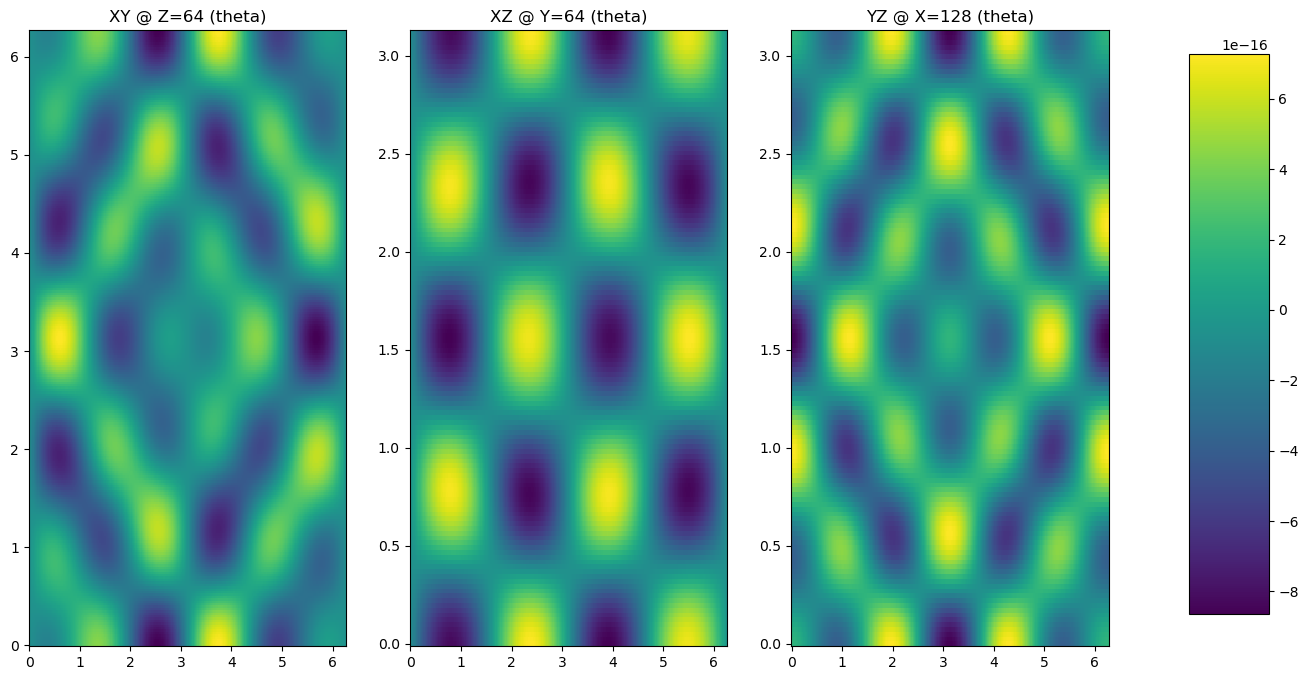

In [64]:
#Plot image slices through T-G vorticies to check

xyidx = 64
xzidx = 64
yzidx = 128

xyslice = u[xyidx,:,:-1]
xzslice = u[:,xzidx,:-1]
yzslice = u[:,:,yzidx]

print(xyslice.shape, np.max(xyslice))
print(xzslice.shape, np.max(xzslice))
print(yzslice.shape, np.max(yzslice))

fig, ax = plt.subplots(1, 3, figsize=(16.0,8.0)) #sharex=True, sharey=True, 

pcm = ax[0].pcolormesh(dx*xIdx[xyidx,:,:],dy*yIdx[xyidx,:,:],xyslice[:,:]) #,vmin=-2.0,vmax=2.0)
pcm = ax[1].pcolormesh(dx*xIdx[:,xzidx,:],dz*zIdx[:,xzidx,:],xzslice[:,:]) #,vmin=-2.0,vmax=2.0)
pcm = ax[2].pcolormesh(dy*yIdx[:,:,yzidx],dz*zIdx[:,:,yzidx],yzslice[:,:]) #,vmin=-2.0,vmax=2.0)

ax[0].title.set_text("XY @ Z="+str(xyidx)+" (theta)")
ax[1].title.set_text("XZ @ Y="+str(xzidx)+" (theta)")
ax[2].title.set_text("YZ @ X="+str(yzidx)+" (theta)")

#ax[0].set_xlim([0,1.5])
#ax[0].set_ylim([0,1.5])
#ax[1].set_xlim([0,1.5])
#ax[1].set_ylim([0,1.5])
#ax[2].set_xlim([0,1.5])
#ax[2].set_ylim([0,1.5])

fig.subplots_adjust(right=0.8)
cbar_ax = fig.add_axes([0.85, 0.15, 0.05, 0.7])
fig.colorbar(pcm, cax=cbar_ax)

plt.show()
#plt.savefig("tgic_v_wind.png")

In [66]:
# Prep state variables for output to wrfinput file, following a few extra conventions...

# 1.) Density in wrfinput is 1.0/(AL+ALB). Must break inverse of total density into mean and perturbation density for ALB and AL, respectively
#     ERF will calculate total density by using the 1.0/(AL+ALB) relationship
inv_density = 1.0/density
mean_density = np.zeros_like(inv_density)
mean_density[:,:,:] = np.mean(inv_density)
pert_density = np.zeros_like(inv_density)
pert_density[:,:,:] = inv_density - mean_density

# 2.) Theta in wrfinput is written as perturbations relative to 300K, so we subtract 300K before writing to file
#     ERF will add 300K back in at read-in
pert_theta = theta[:,:,:] - 300.0

# 3.) Pressure in wrfinput is PB+P, so we must solve for total pressure, then break it apart into PB (base pressure) and P (perturbation pressure).
#     ERF will recombine P and PB to total pressure, and will also check that they satisfy the Equation of State... so the EOS used here MUST match the one in ERF.

# EOS solving for pressure using pressure=rho*theta*(gamma-1)   !!!This must match EOS used in ERF!!!
pressure = density * theta * (polytropicIdx - 1.0)

mean_pressure = np.zeros_like(pressure)
mean_pressure[:,:,:] = np.mean(pressure)
pert_pressure = np.zeros_like(pressure)
pert_pressure[:,:,:] = pressure - mean_pressure

In [76]:
##Write netCDF file based on ERF requirements for WRF variables and atributes
## Refer to ERF_ReadFromWRFInput.cpp

try: outfile.close()
except: pass

outfile = nc.Dataset('wrfinput_TaylorGreen_256x256x128.nc','w')
#print(outfile)

## WRF (Time, Bottom/Top, South/North, West/East) : ALB, AL, U, V, W, T, PH, PHB, PB, P, QVAPOR, QCLOUD, QRAIN
## WRF (Time, South/North, West/East) : MAPFAC_UY, MAPFAC_VY, MAPFAC_MY, MUB, SST, LANDMASK, XLAT_V, XLONG_U
## WRF : C1H, C2H

#C-grid dimensions (cell-centered and staggered)
time_dim = outfile.createDimension('time', None)
dateStrLen_dim = outfile.createDimension('DateStrLen', 19)
bottom_top_dim = outfile.createDimension('BottomTop', Nz)
bottom_top_stag_dim = outfile.createDimension('BottomTopStag', Nz+1)
south_north_dim = outfile.createDimension('SouthNorth', Ny)
south_north_stag_dim = outfile.createDimension('SouthNorthStag', Ny+1)
west_east_dim = outfile.createDimension('WestEast', Nx)
west_east_stag_dim = outfile.createDimension('WestEastStag', Nx+1)
print(outfile)

dims2dcolumn = ('time','BottomTop')

dims3dhplane = ('time','SouthNorth','WestEast')
dims3dhplane_ustag = ('time','SouthNorth','WestEastStag')
dims3dhplane_vstag = ('time','SouthNorthStag','WestEast')

dims4d = ('time','BottomTop','SouthNorth','WestEast')
dims4d_ustag = ('time','BottomTop','SouthNorth','WestEastStag')
dims4d_vstag = ('time','BottomTop','SouthNorthStag','WestEast')
dims4d_wstag = ('time','BottomTopStag','SouthNorth','WestEast')

#Global Attributes required by ERF
outfile.DESCRIPTION = "Python-generated wrfinput file for initialization of ERF with TaylorGreen vorticies on 256x256x128 grid"
outfile.SIMULATION_START_DATE = "0001-01-01_00:00:00"
outfile.DX = dx
outfile.DY = dy
#need to use setncattr for these because attribute name has dash ("-") in name, and python won't allow dashes for variable names
outfile.setncattr("WEST-EAST_GRID_DIMENSION",int(Nx+1))  #based on staggered grid 
outfile.setncattr("SOUTH-NORTH_GRID_DIMENSION",int(Ny+1)) #based on staggered grid

#Times variable (1 single time for initialization)
times_var = outfile.createVariable('Times', 'S1', ('time', 'DateStrLen'))

#C-grid staggered velocities -- Define
uwind_var = outfile.createVariable('U', np.float32, dims4d_ustag)
vwind_var = outfile.createVariable('V', np.float32, dims4d_vstag)
wwind_var = outfile.createVariable('W', np.float32, dims4d_wstag)

#C-grid cell-centered scalars -- Define
theta_var = outfile.createVariable('T', np.float32, dims4d)
press_pert_var = outfile.createVariable('P', np.float32, dims4d)
press_base_var = outfile.createVariable('PB', np.float32, dims4d)
density_pert_var = outfile.createVariable('AL', np.float32, dims4d)
density_base_var = outfile.createVariable('ALB', np.float32, dims4d)
qvapor_var = outfile.createVariable('QVAPOR', np.float32, dims4d)
qcloud_var = outfile.createVariable('QCLOUD', np.float32, dims4d)
qrain_var = outfile.createVariable('QRAIN', np.float32, dims4d)

#C-grid other grid and boundary specifications -- Define
mapfac_uy_var = outfile.createVariable('MAPFAC_UY', np.float32, dims3dhplane_ustag)
mapfac_vy_var = outfile.createVariable('MAPFAC_VY', np.float32, dims3dhplane_vstag)
mapfac_my_var = outfile.createVariable('MAPFAC_MY', np.float32, dims3dhplane)
mub_var = outfile.createVariable('MUB', np.float32, dims3dhplane)
c1h_var = outfile.createVariable('C1H', np.float32, dims2dcolumn)
c2h_var = outfile.createVariable('C2H', np.float32, dims2dcolumn)
xlat_v_var = outfile.createVariable('XLAT_V', np.float32, dims3dhplane_vstag)
xlong_u_var = outfile.createVariable('XLONG_U', np.float32, dims3dhplane_ustag)
sst_var = outfile.createVariable('SST', np.float32, dims3dhplane)
landmask_var = outfile.createVariable('LANDMASK', np.float32, dims3dhplane)

#Times variable -- Write
times_var[:] = ["0001-01-01_00:00:00"]

#C-grid staggered velocities -- Write
uwind_var[0,:,:,:] = u[:,:,:]
vwind_var[0,:,:,:] = v[:,:,:]
wwind_var[0,:,:,:] = w[:,:,:]

#C-grid cell-centered scalars -- Write
theta_var[0,:,:,:] = pert_theta[:,:,:]
press_pert_var[0,:,:,:] = pert_pressure[:,:,:]
press_base_var[0,:,:,:] = mean_pressure[:,:,:]
density_pert_var[0,:,:,:] = pert_density[:,:,:]
density_base_var[0,:,:,:] = mean_density[:,:,:]

#Other C-grid variables requested by ERF, but not needed for this simulation

#This is a DRY simulation, so QVAPOR,QCLOUD,QRAIN will all be zeros
qvapor_var[0,:,:,:] = np.zeros([Nz,Ny,Nx])
qcloud_var[0,:,:,:] = np.zeros([Nz,Ny,Nx])
qrain_var[0,:,:,:] = np.zeros([Nz,Ny,Nx])

#This is an ideal simulation, so all MAPFAC_ variables should equal 1.0
mapfac_uy_var[0,:,:] = np.ones([Ny,Nx+1])
mapfac_vy_var[0,:,:] = np.ones([Ny+1,Nx])
mapfac_my_var[0,:,:] = np.ones([Ny,Nx])

#This is an ideal simulation with no real data, so MUB, C1H, C2H can be set to zeros
#Also, ERF will not use these if solverChoice.use_real_bcs is not set to TRUE
mub_var[0,:,:] = np.zeros([Ny,Nx])
c1h_var[0,:] = np.zeros([Nz])
c2h_var[0,:] = np.zeros([Nz])

#This is an ideal simulation, so XLAT_V, XLONG_U, SST, LANDMASK can be set to zeros
xlat_v_var[0,:,:] = np.zeros([Ny+1,Nx])
xlong_u_var[0,:,:] = np.zeros([Ny,Nx+1])
sst_var[0,:,:] = np.zeros([Ny,Nx])
landmask_var[0,:,:] = np.zeros([Ny,Nx])

print(outfile)

outfile.close()

<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    dimensions(sizes): time(0), DateStrLen(19), BottomTop(128), BottomTopStag(129), SouthNorth(256), SouthNorthStag(257), WestEast(256), WestEastStag(257)
    variables(dimensions): 
    groups: 
<class 'netCDF4._netCDF4.Dataset'>
root group (NETCDF4 data model, file format HDF5):
    DESCRIPTION: Python-generated wrfinput file for initialization of ERF with TaylorGreen vorticies on 256x256x128 grid
    SIMULATION_START_DATE: 0001-01-01_00:00:00
    DX: 0.02454369260617026
    DY: 0.02454369260617026
    WEST-EAST_GRID_DIMENSION: 257
    SOUTH-NORTH_GRID_DIMENSION: 257
    dimensions(sizes): time(1), DateStrLen(19), BottomTop(128), BottomTopStag(129), SouthNorth(256), SouthNorthStag(257), WestEast(256), WestEastStag(257)
    variables(dimensions): |S1 Times(time, DateStrLen), float32 U(time, BottomTop, SouthNorth, WestEastStag), float32 V(time, BottomTop, SouthNorthStag, WestEast), float32 W(time, Bot